In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import shap
import matplotlib.pyplot as plt

RANDOM_STATE = 42
BACKGROUND_N = 100
EXPLAIN_N = 100

MODEL_DIR = "../models"
OUT_DIR = "explainability_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

/Users/swethachakravarthy/Projects/incident-intelligence/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
models = {}

for fn in os.listdir(MODEL_DIR):
    if fn.endswith(".pkl"):
        b = joblib.load(os.path.join(MODEL_DIR, fn))
        name = fn.replace(".pkl", "")

        # normalize y_test key
        if "y_test" not in b and "Y_test" in b:
            b["y_test"] = b["Y_test"]

        # sanity
        for k in ["scaler", "clf", "feature_columns", "X_test", "y_test"]:
            if k not in b:
                raise KeyError(f"{name} missing key: {k}")

        models[name] = b

print("Loaded models:", list(models.keys()))

Loaded models: ['SVM', 'Gradient_Boosting', 'Logistic_Regression', 'Random_Forest']


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def transform_X(bundle, X_raw: pd.DataFrame) -> pd.DataFrame:
    feat_cols = bundle["feature_columns"]
    scaler = bundle.get("scaler", None)

    X = X_raw[feat_cols].copy()
    if scaler is not None:
        X = scaler.transform(X)  # stays DataFrame because of set_output(transform="pandas")
    return X

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import shap

def make_explainer(clf, X_bg: pd.DataFrame):
    # Skip SHAP for multiclass sklearn GradientBoostingClassifier
    if isinstance(clf, GradientBoostingClassifier):
        n_classes = len(getattr(clf, "classes_", []))
        if n_classes > 2:
            return None, "skip_gb_multiclass"
        return shap.TreeExplainer(clf), "tree"

    # RandomForest and other tree models
    if isinstance(clf, RandomForestClassifier) or hasattr(clf, "feature_importances_"):
        return shap.TreeExplainer(clf), "tree"

    # Logistic Regression
    if isinstance(clf, LogisticRegression):
        return shap.LinearExplainer(clf, X_bg), "linear"

    # SVM
    if isinstance(clf, SVC):
        if clf.kernel == "linear":
            return shap.LinearExplainer(clf, X_bg), "linear"
        return shap.KernelExplainer(clf.predict_proba, X_bg.to_numpy()), "kernel"

    # fallback
    if hasattr(clf, "predict_proba"):
        return shap.KernelExplainer(clf.predict_proba, X_bg.to_numpy()), "kernel"

    raise ValueError(f"Unsupported model type: {type(clf)}")

def normalize_multiclass_shap(shap_out, n_classes: int):
    """Return list[class] -> (n_samples, n_features)."""
    if isinstance(shap_out, list):
        return shap_out
    arr = np.asarray(shap_out)
    if arr.ndim == 3 and arr.shape[2] == n_classes:
        return [arr[:, :, i] for i in range(n_classes)]
    raise ValueError(f"Unsupported multiclass SHAP shape: {arr.shape}")


===== SVM =====
Using Kernel SHAP (slow)


100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


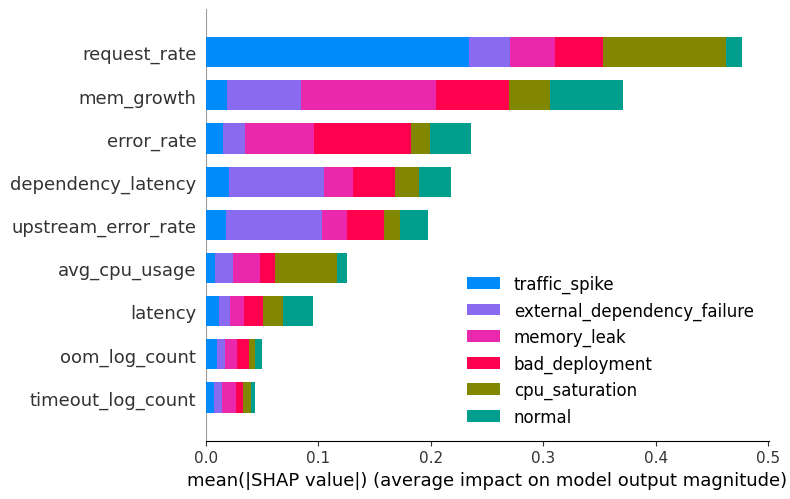

Top features: ['request_rate', 'mem_growth', 'error_rate', 'dependency_latency', 'upstream_error_rate', 'avg_cpu_usage', 'latency', 'oom_log_count', 'timeout_log_count']
Runtime: 48.35 seconds

===== Gradient_Boosting =====
Using permutation importance (GB multiclass SHAP unsupported)


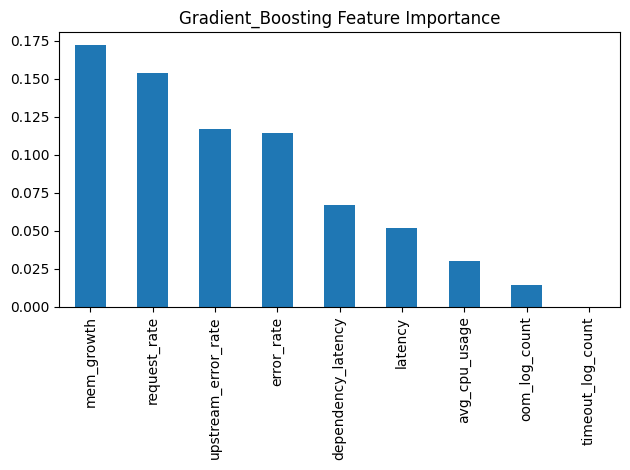

Top features: ['mem_growth', 'request_rate', 'upstream_error_rate', 'error_rate', 'dependency_latency', 'latency', 'avg_cpu_usage', 'oom_log_count', 'timeout_log_count']
Runtime: 2.1 seconds

===== Logistic_Regression =====


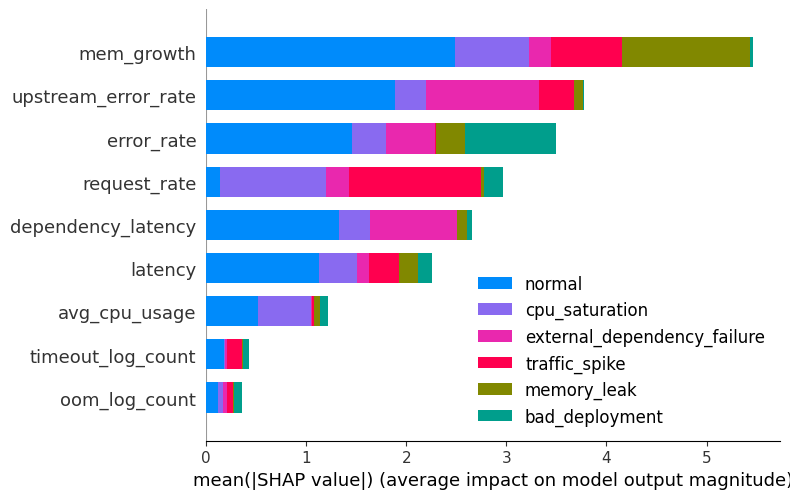

Top features: ['mem_growth', 'upstream_error_rate', 'error_rate', 'request_rate', 'dependency_latency', 'latency', 'avg_cpu_usage', 'timeout_log_count', 'oom_log_count']
Runtime: 0.07 seconds

===== Random_Forest =====


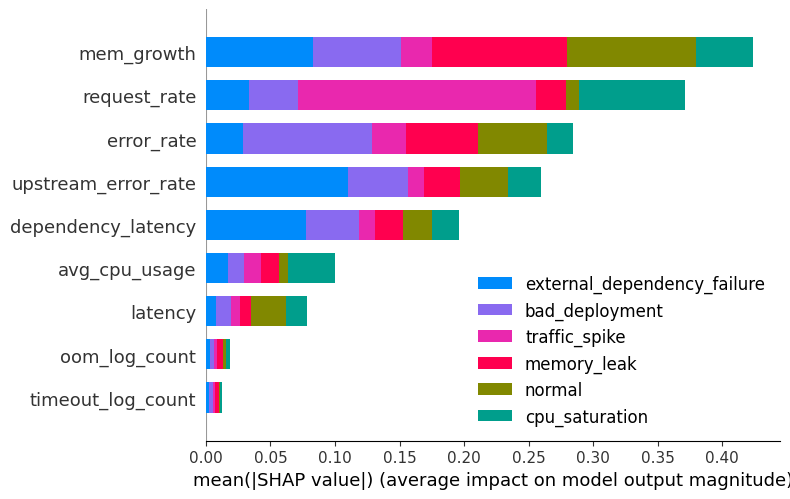

Top features: ['mem_growth', 'request_rate', 'error_rate', 'upstream_error_rate', 'dependency_latency', 'avg_cpu_usage', 'latency', 'oom_log_count', 'timeout_log_count']
Runtime: 0.76 seconds


,model,method,runtime_sec,top_features
0,SVM,shap_kernel,48.35,"[request_rate, mem_growth, error_rate, depende..."
1,Gradient_Boosting,permutation,2.10,"[mem_growth, request_rate, upstream_error_rate..."
2,Logistic_Regression,shap_linear,0.07,"[mem_growth, upstream_error_rate, error_rate, ..."
3,Random_Forest,shap_tree,0.76,"[mem_growth, request_rate, error_rate, upstrea..."


In [4]:
import time
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingClassifier

KERNEL_BG = 40
KERNEL_NSAMPLES = 80

rows = []

for name, b in models.items():

    clf = b["clf"]
    X_test_raw = b["X_test"]
    y_test = b["y_test"]
    classes = list(clf.classes_)

    print(f"\n===== {name} =====")

    # Sample background + explain data
    X_bg = transform_X(
        b,
        X_test_raw.sample(min(BACKGROUND_N, len(X_test_raw)), random_state=RANDOM_STATE)
    )

    X_ex = transform_X(
        b,
        X_test_raw.sample(min(EXPLAIN_N, len(X_test_raw)), random_state=RANDOM_STATE)
    )

    start = time.time()

    # --------------------------------------------------
    # GradientBoosting multiclass -> permutation fallback
    # --------------------------------------------------
    if isinstance(clf, GradientBoostingClassifier) and len(classes) > 2:

        print("Using permutation importance (GB multiclass SHAP unsupported)")

        perm = permutation_importance(
            clf,
            X_ex,
            y_test.loc[X_ex.index],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        importance = pd.Series(
            perm.importances_mean,
            index=X_ex.columns
        ).sort_values(ascending=False)

        method = "permutation"

        # Plot
        importance.head(20).plot(kind="bar", title=f"{name} Feature Importance")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/{name}_importance.png", dpi=200)
        plt.show()

    else:

        # Determine SHAP type
        explainer, kind = make_explainer(clf, X_bg)
        method = f"shap_{kind}"

        if kind == "kernel":

            print("Using Kernel SHAP (slow)")

            # Reduce background
            X_bg_small = shap.sample(X_bg, KERNEL_BG)

            explainer = shap.KernelExplainer(
                clf.predict_proba,
                X_bg_small.to_numpy()
            )

            shap_vals = explainer.shap_values(
                X_ex.to_numpy(),
                nsamples=KERNEL_NSAMPLES
            )

        else:

            shap_vals = explainer.shap_values(X_ex)

        shap_list = normalize_multiclass_shap(shap_vals, len(classes))

        # Global importance
        importance = pd.Series(
            np.mean(np.abs(np.vstack(shap_list)), axis=0),
            index=X_ex.columns
        ).sort_values(ascending=False)

        # Plot
        shap.summary_plot(shap_list, X_ex, class_names=classes, plot_type="bar")

    runtime = round(time.time() - start, 2)

    print("Top features:", list(importance.head(10).index))
    print("Runtime:", runtime, "seconds")

    rows.append({
        "model": name,
        "method": method,
        "runtime_sec": runtime,
        "top_features": list(importance.head(10).index)
    })

summary = pd.DataFrame(rows)
summary


MODEL: SVM | classes=6
Local explainer kind: kernel

------------------------------------------------------------------------------------------
row: 2434 | true: cpu_saturation | pred: memory_leak


100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

Predicted: memory_leak


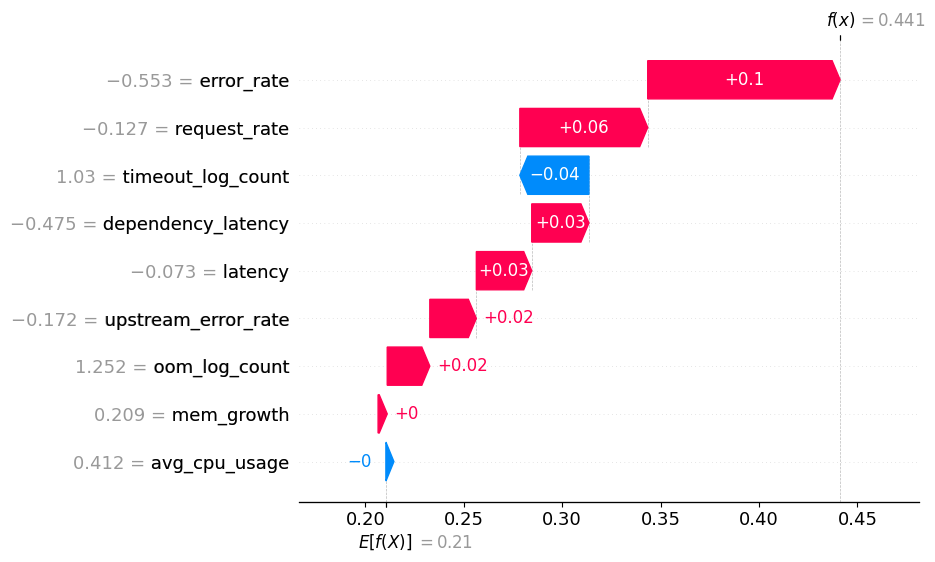

100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Top-K predicted causes + top contributing features:

  memory_leak  (p=0.441)


,feature,shap_value
0,error_rate,0.103716
1,request_rate,0.064399
2,timeout_log_count,-0.033296
3,dependency_latency,0.029889
4,latency,0.027515
5,oom_log_count,0.020323
6,upstream_error_rate,0.017391
7,mem_growth,0.005873



  cpu_saturation  (p=0.258)


,feature,shap_value
0,mem_growth,0.043514
1,request_rate,0.041162
2,upstream_error_rate,0.016808
3,latency,-0.014672
4,timeout_log_count,0.013753
5,avg_cpu_usage,0.009358
6,error_rate,0.005048
7,dependency_latency,-0.003053



  bad_deployment  (p=0.195)


,feature,shap_value
0,error_rate,-0.111224
1,request_rate,0.029927
2,dependency_latency,0.027947
3,timeout_log_count,0.016282
4,upstream_error_rate,0.015723
5,oom_log_count,0.013892
6,latency,0.012123
7,avg_cpu_usage,0.009145



------------------------------------------------------------------------------------------
row: 2176 | true: memory_leak | pred: bad_deployment


100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Predicted: bad_deployment


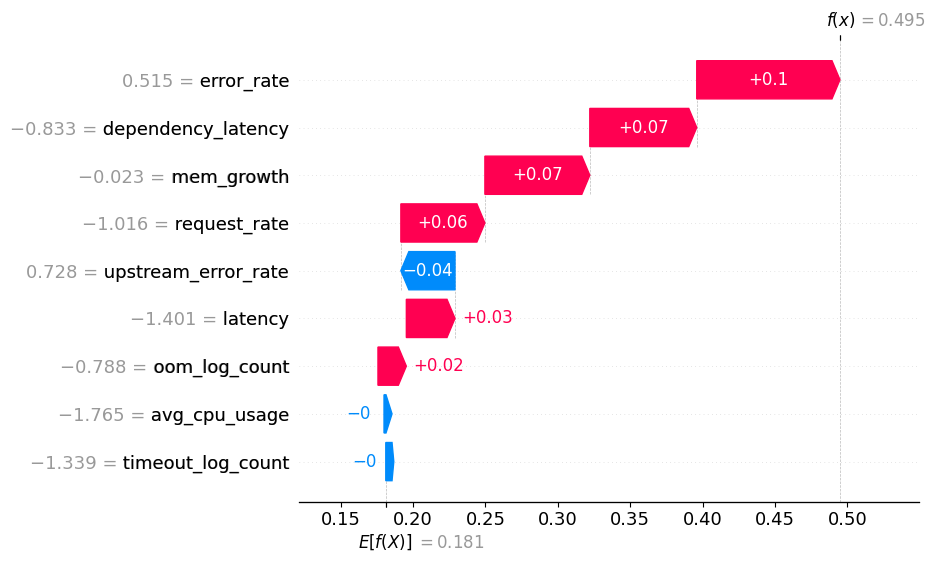

100%|██████████| 1/1 [00:00<00:00,  2.21it/s]

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.495)


,feature,shap_value
0,error_rate,0.094124
1,dependency_latency,0.084298
2,mem_growth,0.068132
3,request_rate,0.060998
4,upstream_error_rate,-0.034221
5,latency,0.029681
6,oom_log_count,0.018990
7,avg_cpu_usage,-0.005270



  memory_leak  (p=0.178)


,feature,shap_value
0,error_rate,-0.090016
1,avg_cpu_usage,0.081400
2,mem_growth,-0.066640
3,dependency_latency,0.045531
4,request_rate,0.031168
5,upstream_error_rate,-0.025158
6,oom_log_count,-0.008575
7,latency,0.002583



  external_dependency_failure  (p=0.176)


,feature,shap_value
0,dependency_latency,-0.130956
1,upstream_error_rate,0.085528
2,request_rate,0.026542
3,latency,-0.020552
4,mem_growth,0.018294
5,error_rate,0.015599
6,oom_log_count,-0.010782
7,avg_cpu_usage,0.008966



------------------------------------------------------------------------------------------
row: 3320 | true: bad_deployment | pred: bad_deployment


100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Predicted: bad_deployment


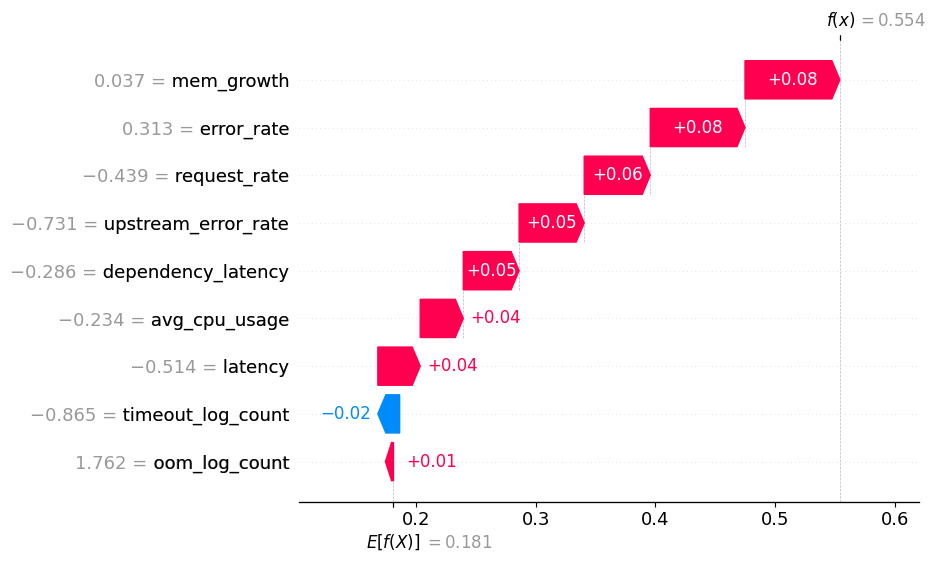

100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.554)


,feature,shap_value
0,mem_growth,0.080569
1,error_rate,0.078296
2,upstream_error_rate,0.057318
3,request_rate,0.052928
4,dependency_latency,0.044960
5,avg_cpu_usage,0.036864
6,latency,0.034161
7,timeout_log_count,-0.017677



  cpu_saturation  (p=0.222)


,feature,shap_value
0,request_rate,0.073622
1,avg_cpu_usage,-0.039922
2,error_rate,0.029773
3,latency,-0.027669
4,dependency_latency,0.011439
5,oom_log_count,0.009526
6,upstream_error_rate,0.007904
7,mem_growth,0.007749



  memory_leak  (p=0.133)


,feature,shap_value
0,error_rate,-0.095420
1,mem_growth,-0.059688
2,request_rate,0.020537
3,upstream_error_rate,0.019209
4,oom_log_count,0.015199
5,timeout_log_count,0.011607
6,dependency_latency,0.004249
7,avg_cpu_usage,0.003810



MODEL: Gradient_Boosting | classes=6
Local explainer kind: kernel

------------------------------------------------------------------------------------------
row: 2434 | true: cpu_saturation | pred: memory_leak


100%|██████████| 1/1 [00:00<00:00, 61.32it/s]

Predicted: memory_leak


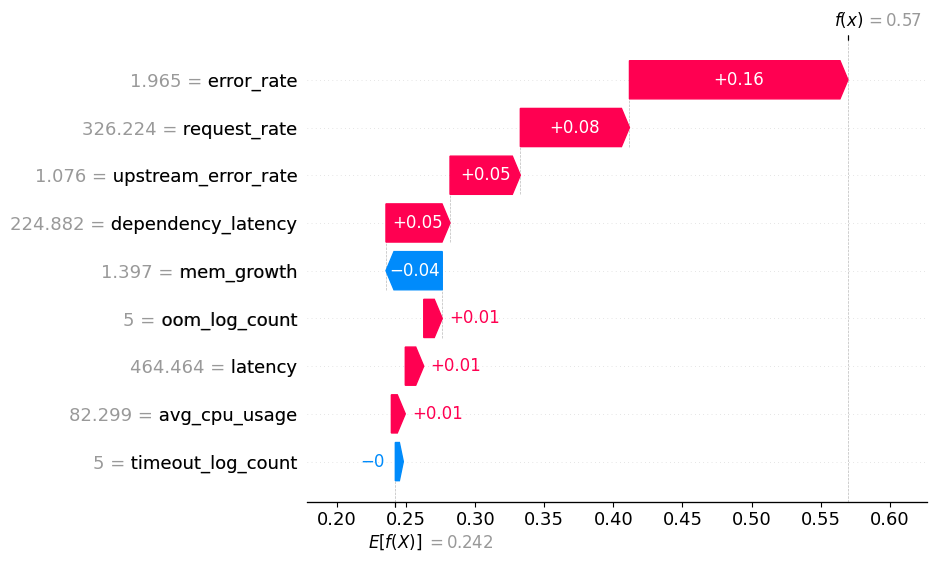

100%|██████████| 1/1 [00:00<00:00, 69.39it/s]

Top-K predicted causes + top contributing features:

  memory_leak  (p=0.570)


,feature,shap_value
0,error_rate,0.156974
1,request_rate,0.080681
2,upstream_error_rate,0.050545
3,dependency_latency,0.047551
4,mem_growth,-0.041160
5,oom_log_count,0.013364
6,latency,0.013063
7,avg_cpu_usage,0.008962



  cpu_saturation  (p=0.195)


,feature,shap_value
0,request_rate,0.057347
1,mem_growth,0.039846
2,avg_cpu_usage,-0.022760
3,upstream_error_rate,0.014622
4,latency,-0.014589
5,oom_log_count,-0.012134
6,dependency_latency,-0.004592
7,error_rate,0.004289



  bad_deployment  (p=0.117)


,feature,shap_value
0,error_rate,-0.166637
1,dependency_latency,0.028089
2,upstream_error_rate,0.025498
3,request_rate,0.022872
4,mem_growth,0.013903
5,avg_cpu_usage,0.010122
6,oom_log_count,0.005015
7,latency,0.004751



------------------------------------------------------------------------------------------
row: 2176 | true: memory_leak | pred: bad_deployment


100%|██████████| 1/1 [00:00<00:00, 65.24it/s]


Predicted: bad_deployment


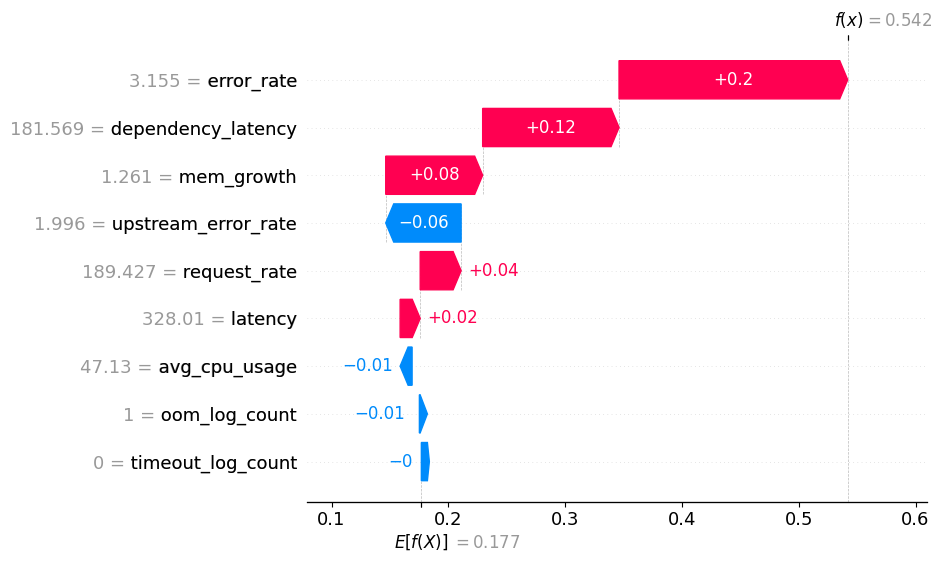

100%|██████████| 1/1 [00:00<00:00, 66.66it/s]

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.542)


,feature,shap_value
0,error_rate,0.195656
1,dependency_latency,0.117587
2,mem_growth,0.082812
3,upstream_error_rate,-0.066198
4,request_rate,0.036879
5,latency,0.016456
6,avg_cpu_usage,-0.012512
7,oom_log_count,-0.003198



  external_dependency_failure  (p=0.221)


,feature,shap_value
0,dependency_latency,-0.152265
1,upstream_error_rate,0.116150
2,mem_growth,0.035241
3,avg_cpu_usage,0.028536
4,request_rate,0.020777
5,error_rate,0.008763
6,latency,-0.002430
7,oom_log_count,-0.002372



  cpu_saturation  (p=0.181)


,feature,shap_value
0,request_rate,0.111069
1,avg_cpu_usage,-0.076555
2,error_rate,0.046694
3,latency,-0.022638
4,dependency_latency,-0.015476
5,mem_growth,-0.009897
6,oom_log_count,0.009124
7,upstream_error_rate,0.004950



------------------------------------------------------------------------------------------
row: 3320 | true: bad_deployment | pred: bad_deployment


100%|██████████| 1/1 [00:00<00:00, 64.08it/s]


Predicted: bad_deployment


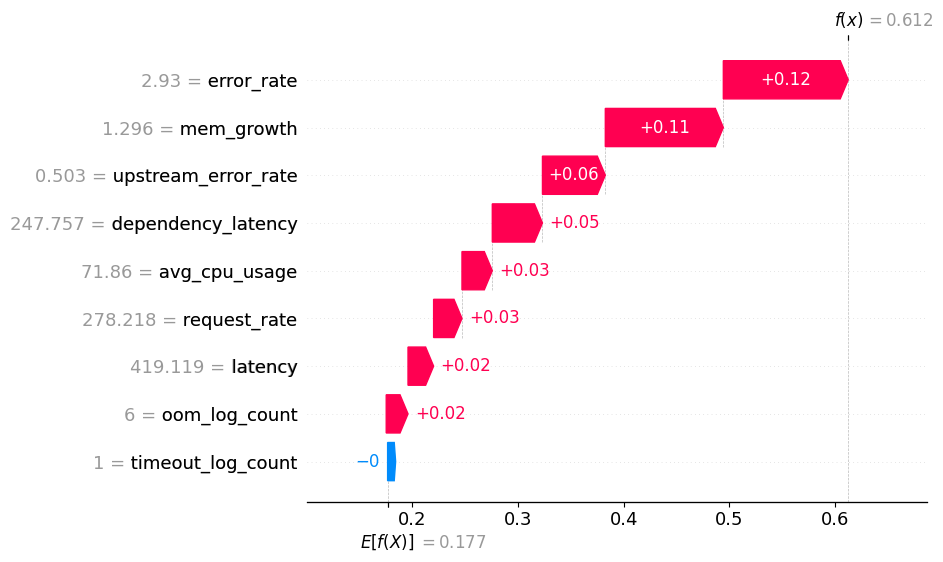

100%|██████████| 1/1 [00:00<00:00, 69.37it/s]

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.612)


,feature,shap_value
0,error_rate,0.119059
1,mem_growth,0.110837
2,upstream_error_rate,0.058438
3,dependency_latency,0.045163
4,avg_cpu_usage,0.030593
5,request_rate,0.027866
6,latency,0.024301
7,oom_log_count,0.021379



  cpu_saturation  (p=0.208)


,feature,shap_value
0,request_rate,0.081782
1,avg_cpu_usage,-0.045938
2,dependency_latency,0.041178
3,latency,-0.023821
4,error_rate,0.023194
5,oom_log_count,-0.016274
6,upstream_error_rate,0.014986
7,timeout_log_count,-0.000998



  memory_leak  (p=0.101)


,feature,shap_value
0,error_rate,-0.115792
1,mem_growth,-0.073468
2,request_rate,0.024816
3,upstream_error_rate,0.014645
4,dependency_latency,-0.011587
5,avg_cpu_usage,0.011495
6,timeout_log_count,0.004041
7,latency,0.003789



MODEL: Logistic_Regression | classes=6
Local explainer kind: linear

------------------------------------------------------------------------------------------
row: 2434 | true: cpu_saturation | pred: memory_leak
Predicted: memory_leak


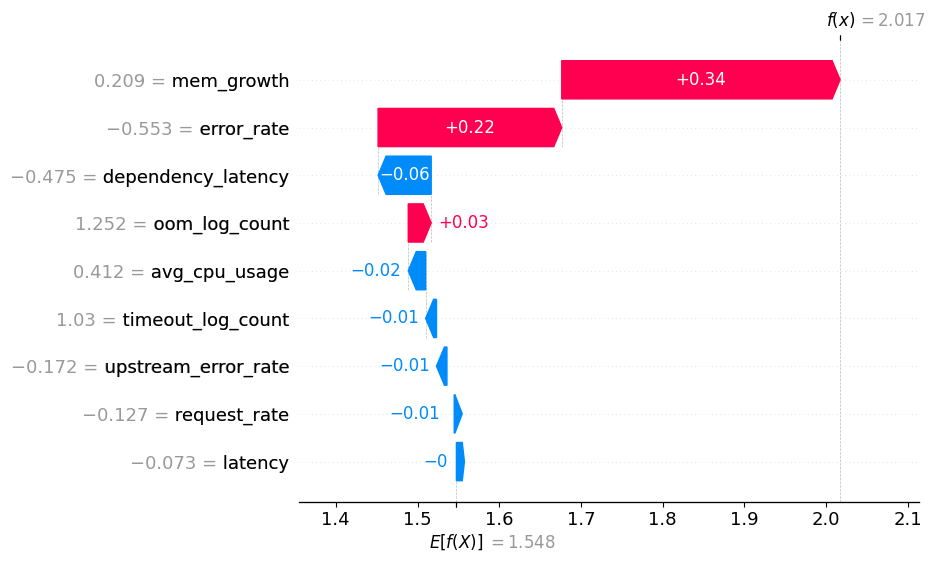

Top-K predicted causes + top contributing features:

  memory_leak  (p=0.339)


,feature,shap_value
0,mem_growth,0.340608
1,error_rate,0.224741
2,dependency_latency,-0.064976
3,oom_log_count,0.028055
4,avg_cpu_usage,-0.021280
5,timeout_log_count,-0.013237
6,upstream_error_rate,-0.012797
7,request_rate,-0.008929



  cpu_saturation  (p=0.260)


,feature,shap_value
0,request_rate,0.334256
1,error_rate,-0.262354
2,dependency_latency,-0.199089
3,mem_growth,0.195428
4,avg_cpu_usage,0.167534
5,oom_log_count,0.092340
6,upstream_error_rate,-0.047255
7,timeout_log_count,0.016230



  bad_deployment  (p=0.177)


,feature,shap_value
0,error_rate,-0.712066
1,oom_log_count,0.142612
2,timeout_log_count,0.074973
3,request_rate,0.060606
4,dependency_latency,-0.031594
5,avg_cpu_usage,0.023539
6,mem_growth,-0.005971
7,latency,-0.001972



------------------------------------------------------------------------------------------
row: 2176 | true: memory_leak | pred: external_dependency_failure
Predicted: external_dependency_failure


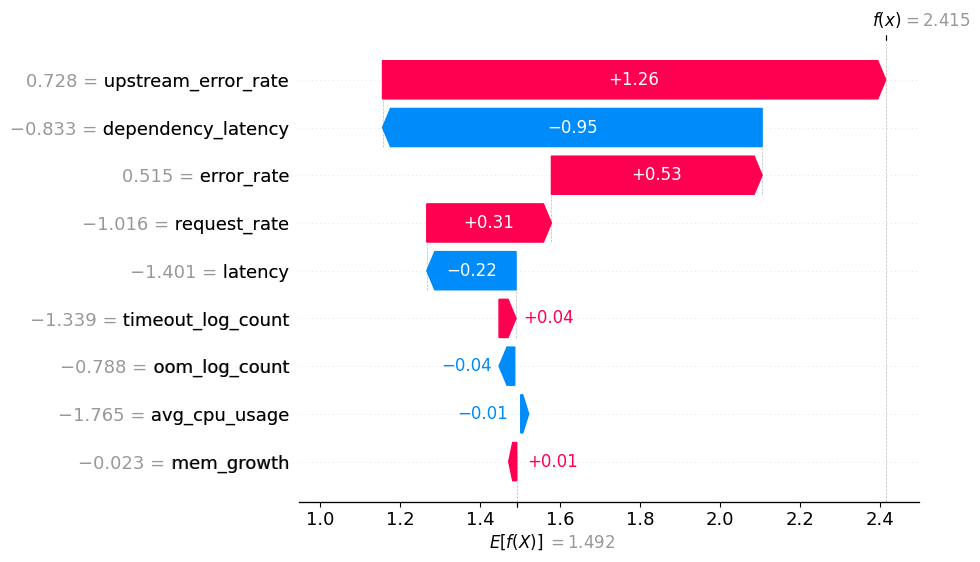

Top-K predicted causes + top contributing features:

  external_dependency_failure  (p=0.388)


,feature,shap_value
0,upstream_error_rate,1.258745
1,dependency_latency,-0.949498
2,error_rate,0.527013
3,request_rate,0.311785
4,latency,-0.223289
5,timeout_log_count,0.042527
6,oom_log_count,-0.039324
7,avg_cpu_usage,-0.014918



  bad_deployment  (p=0.381)


,feature,shap_value
0,error_rate,0.964620
1,latency,-0.253038
2,request_rate,0.250922
3,avg_cpu_usage,-0.155708
4,oom_log_count,-0.092140
5,timeout_log_count,-0.091633
6,dependency_latency,-0.053760
7,upstream_error_rate,0.008924



  cpu_saturation  (p=0.125)


,feature,shap_value
0,request_rate,1.383898
1,avg_cpu_usage,-1.108232
2,latency,-0.706693
3,error_rate,0.355405
4,upstream_error_rate,0.353627
5,dependency_latency,-0.338771
6,oom_log_count,-0.059660
7,mem_growth,-0.034004



------------------------------------------------------------------------------------------
row: 3320 | true: bad_deployment | pred: bad_deployment
Predicted: bad_deployment


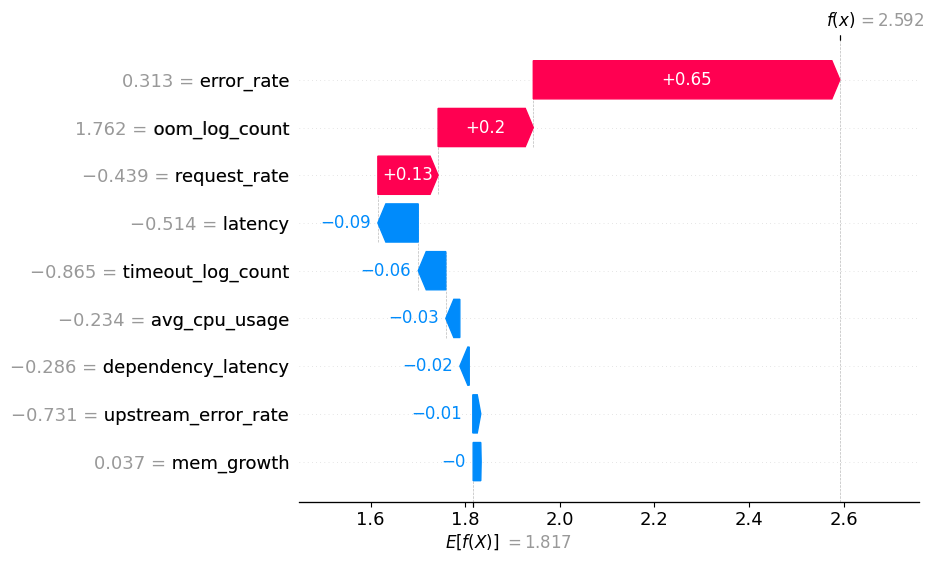

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.541)


,feature,shap_value
0,error_rate,0.648295
1,oom_log_count,0.201300
2,request_rate,0.127393
3,latency,-0.085404
4,timeout_log_count,-0.058312
5,avg_cpu_usage,-0.029667
6,dependency_latency,-0.019887
7,upstream_error_rate,-0.007482



  cpu_saturation  (p=0.216)


,feature,shap_value
0,request_rate,0.702603
1,upstream_error_rate,-0.296476
2,error_rate,0.238858
3,latency,-0.238519
4,avg_cpu_usage,-0.211151
5,oom_log_count,0.130340
6,dependency_latency,-0.125318
7,mem_growth,0.025289



  memory_leak  (p=0.136)


,feature,shap_value
0,error_rate,-0.204614
1,latency,-0.116066
2,upstream_error_rate,-0.080289
3,mem_growth,0.044075
4,dependency_latency,-0.040900
5,oom_log_count,0.039601
6,avg_cpu_usage,0.026820
7,request_rate,-0.018770



MODEL: Random_Forest | classes=6
Local explainer kind: tree

------------------------------------------------------------------------------------------
row: 2434 | true: cpu_saturation | pred: memory_leak
Predicted: memory_leak


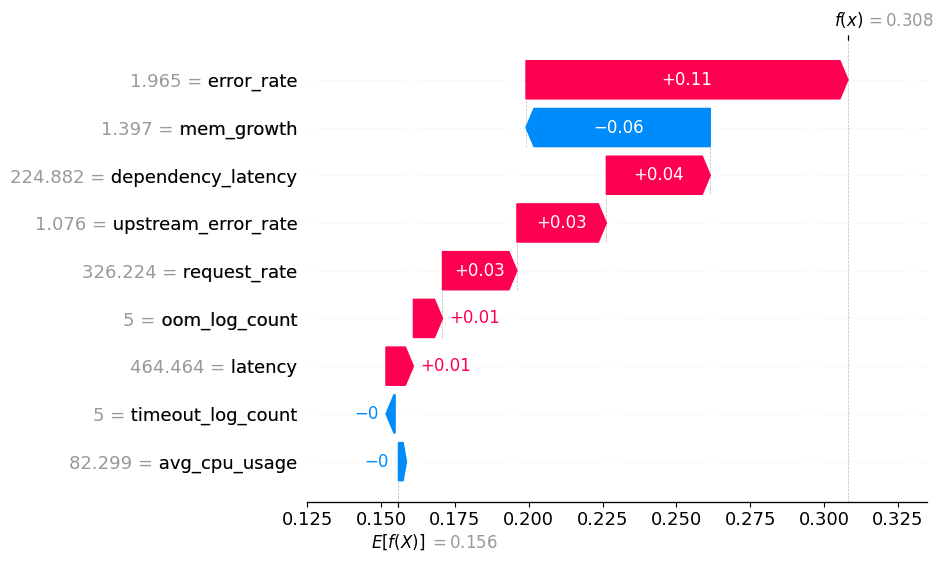

Top-K predicted causes + top contributing features:

  memory_leak  (p=0.308)


,feature,shap_value
0,error_rate,0.109111
1,mem_growth,-0.062447
2,dependency_latency,0.035214
3,upstream_error_rate,0.030298
4,request_rate,0.025233
5,oom_log_count,0.009856
6,latency,0.009293
7,timeout_log_count,-0.003087



  bad_deployment  (p=0.263)


,feature,shap_value
0,error_rate,-0.144903
1,upstream_error_rate,0.055576
2,mem_growth,0.054131
3,request_rate,0.043035
4,dependency_latency,0.040438
5,latency,0.015644
6,avg_cpu_usage,0.008830
7,oom_log_count,-0.005065



  cpu_saturation  (p=0.227)


,feature,shap_value
0,request_rate,0.045428
1,upstream_error_rate,0.027516
2,mem_growth,0.021111
3,dependency_latency,-0.014220
4,latency,-0.011558
5,error_rate,0.009744
6,avg_cpu_usage,-0.007542
7,oom_log_count,0.000885



------------------------------------------------------------------------------------------
row: 2176 | true: memory_leak | pred: bad_deployment
Predicted: bad_deployment


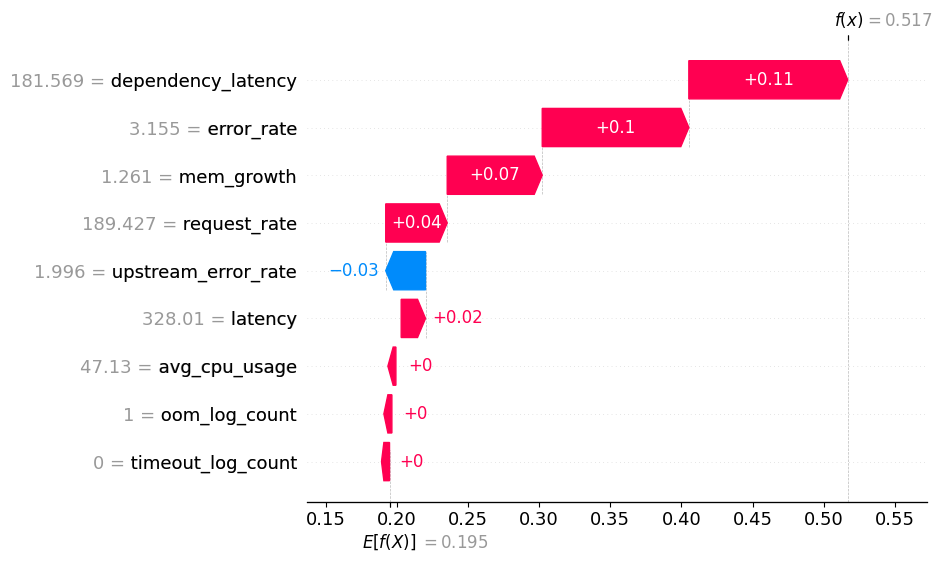

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.517)


,feature,shap_value
0,dependency_latency,0.111640
1,error_rate,0.103005
2,mem_growth,0.066760
3,request_rate,0.043207
4,upstream_error_rate,-0.027966
5,latency,0.017103
6,avg_cpu_usage,0.003715
7,oom_log_count,0.002823



  external_dependency_failure  (p=0.169)


,feature,shap_value
0,dependency_latency,-0.171636
1,upstream_error_rate,0.085725
2,mem_growth,0.029172
3,latency,-0.022629
4,request_rate,0.020892
5,error_rate,0.020519
6,avg_cpu_usage,0.012069
7,timeout_log_count,-0.002441



  cpu_saturation  (p=0.156)


,feature,shap_value
0,request_rate,0.044159
1,avg_cpu_usage,-0.032430
2,error_rate,0.025817
3,latency,-0.022702
4,upstream_error_rate,-0.009874
5,dependency_latency,-0.009058
6,mem_growth,0.005085
7,oom_log_count,-0.001745



------------------------------------------------------------------------------------------
row: 3320 | true: bad_deployment | pred: bad_deployment
Predicted: bad_deployment


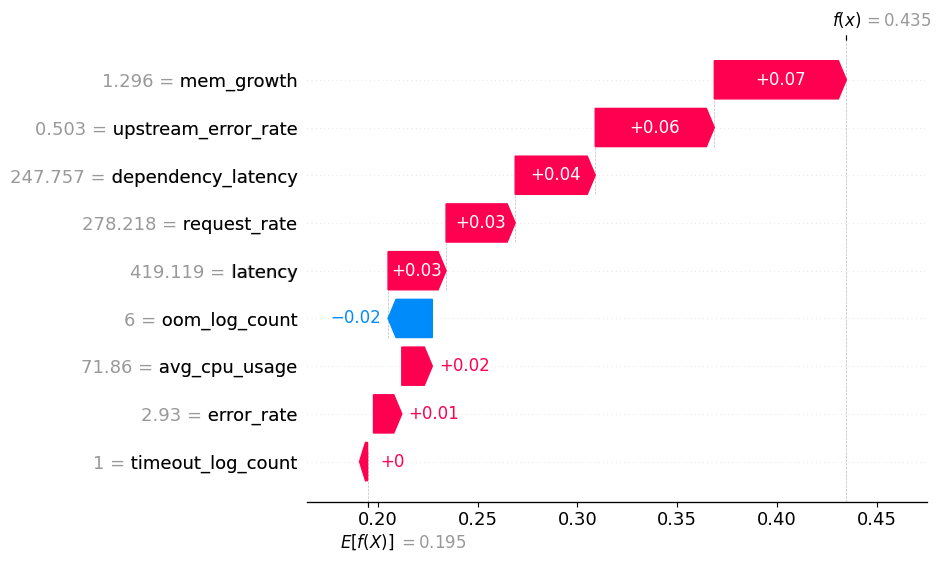

Top-K predicted causes + top contributing features:

  bad_deployment  (p=0.435)


,feature,shap_value
0,mem_growth,0.066164
1,upstream_error_rate,0.059679
2,dependency_latency,0.040105
3,request_rate,0.034628
4,latency,0.029062
5,oom_log_count,-0.022176
6,avg_cpu_usage,0.015300
7,error_rate,0.014172



  cpu_saturation  (p=0.232)


,feature,shap_value
0,request_rate,0.048782
1,error_rate,0.043668
2,avg_cpu_usage,-0.031191
3,latency,-0.022472
4,dependency_latency,0.016932
5,upstream_error_rate,0.008168
6,oom_log_count,0.006508
7,mem_growth,0.005984



  external_dependency_failure  (p=0.145)


,feature,shap_value
0,upstream_error_rate,-0.113623
1,dependency_latency,-0.066962
2,mem_growth,0.058152
3,error_rate,0.045045
4,request_rate,0.018443
5,avg_cpu_usage,0.011366
6,latency,-0.009002
7,oom_log_count,0.005965


In [5]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

KERNEL_BG_LOCAL = 30
KERNEL_NSAMPLES_LOCAL = 100

def build_explainer_for_model(b, X_bg, classes):
    """
    Returns (explainer, kind) where kind in {"tree","linear","kernel"}.
    Uses KernelExplainer for multiclass sklearn GradientBoostingClassifier.
    """
    clf = b["clf"]

    # Force kernel for multiclass GradientBoosting
    if isinstance(clf, GradientBoostingClassifier) and len(classes) > 2:
        X_bg_small = shap.sample(X_bg, min(KERNEL_BG_LOCAL, len(X_bg)))
        explainer = shap.KernelExplainer(clf.predict_proba, X_bg_small.to_numpy())
        return explainer, "kernel"

    # Otherwise use your existing logic
    explainer, kind = make_explainer(clf, X_bg)

    # If the chosen path is kernel (e.g., SVM rbf), rebuild with reduced background
    if kind == "kernel":
        X_bg_small = shap.sample(X_bg, min(KERNEL_BG_LOCAL, len(X_bg)))
        explainer = shap.KernelExplainer(clf.predict_proba, X_bg_small.to_numpy())

    return explainer, kind

def get_shap_list_for_one(explainer, kind, x_one_df, n_classes):
    """
    Returns list[class] -> (1, n_features).
    """
    if kind == "kernel":
        shap_one = explainer.shap_values(
            x_one_df.to_numpy(),
            nsamples=KERNEL_NSAMPLES_LOCAL
        )
    else:
        shap_one = explainer.shap_values(x_one_df)

    return normalize_multiclass_shap(shap_one, n_classes=n_classes)

def _get_base_value(explainer, class_index):
    """
    Robust base value extraction for multiclass explainers.
    """
    base = getattr(explainer, "expected_value", None)
    if base is None:
        return None
    if isinstance(base, (list, np.ndarray)):
        base = np.asarray(base).reshape(-1)
        if len(base) > class_index:
            return float(base[class_index])
        return float(base[0])
    return float(base)

def local_waterfall_for_pred_class(explainer, kind, clf, x_one_df, classes):
    pred = clf.predict(x_one_df)[0]
    ci = list(classes).index(pred)

    shap_list = get_shap_list_for_one(explainer, kind, x_one_df, n_classes=len(classes))
    sv = shap_list[ci][0]  # (n_features,)

    base = _get_base_value(explainer, ci)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x_one_df.iloc[0].values,
        feature_names=list(x_one_df.columns),
    )

    print("Predicted:", pred)
    shap.plots.waterfall(exp, max_display=20)
    plt.show()

def topk_rca(explainer, kind, clf, x_one_df, classes, k=3, top_feats=8):
    proba = clf.predict_proba(x_one_df)[0]
    order = np.argsort(proba)[::-1][:k]

    shap_list = get_shap_list_for_one(explainer, kind, x_one_df, n_classes=len(classes))

    results = []
    for ci in order:
        c = classes[ci]
        p = float(proba[ci])

        sv = shap_list[ci][0]
        s = (
            pd.Series(sv, index=x_one_df.columns)
            .sort_values(key=np.abs, ascending=False)
            .head(top_feats)
        )

        results.append((c, p, s))
    return results

# -----------------------
# RUN A FEW EXAMPLES
# -----------------------
N_EXAMPLES = 3
K = 3
TOP_FEATS = 8

for name, b in models.items():
    clf = b["clf"]
    X_test_raw = b["X_test"]
    y_test = b["y_test"]
    classes = list(clf.classes_)

    print("\n" + "="*110)
    print(f"MODEL: {name} | classes={len(classes)}")

    # Background (test-only in your bundles)
    X_bg = transform_X(b, X_test_raw.sample(min(BACKGROUND_N, len(X_test_raw)), random_state=RANDOM_STATE))
    explainer, kind = build_explainer_for_model(b, X_bg, classes)
    print("Local explainer kind:", kind)

    # Choose examples
    idxs = list(X_test_raw.sample(min(N_EXAMPLES, len(X_test_raw)), random_state=RANDOM_STATE).index)

    for idx in idxs:
        x_one_raw = X_test_raw.loc[[idx]]
        x_one = transform_X(b, x_one_raw)  # DataFrame (pandas output scaler)
        true = y_test.loc[idx]
        pred = clf.predict(x_one)[0]

        print("\n" + "-"*90)
        print(f"row: {idx} | true: {true} | pred: {pred}")

        # Local waterfall
        local_waterfall_for_pred_class(explainer, kind, clf, x_one, classes)

        # Top-K RCA
        topk = topk_rca(explainer, kind, clf, x_one, classes, k=K, top_feats=TOP_FEATS)
        print("Top-K predicted causes + top contributing features:")
        for c, p, s in topk:
            print(f"\n  {c}  (p={p:.3f})")
            display(pd.DataFrame({"feature": s.index, "shap_value": s.values}))